# SHAP Analysis
Notebook for SHAP interpretation and feature importance.

In [1]:
# ── 0. imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import warnings

warnings.filterwarnings("ignore")

matched_df = pd.read_parquet("../data/cohort_matched.parquet")

print(f"Matched cohort: {len(matched_df):,} rows")
print(f"28-day mortality rate: {matched_df['event_observed'].mean():.1%}")


Matched cohort: 7,832 rows
28-day mortality rate: 24.7%


In [2]:
# ── 1. why a separate model for SHAP ─────────────────────────────────────────
# Cox PH gives hazard ratios — interpretable but linear and parametric
# SHAP on a gradient boosted classifier captures non-linear feature effects
# and interaction terms the Cox model misses
#
# This notebook answers: "which patient features most strongly predict
# 28-day mortality, and in what direction?" — a question clinicians actually ask

FEATURES = [
    "treatment_group",
    "age_at_admission",
    "icu_los_days",
    "total_fluid_ml",
    "bun",
    "creatinine",
    "bilirubin",
    "platelets",
    "wbc",
    "lactate",
    "bicarbonate",
]

TARGET = "event_observed"  # 28-day mortality (1 = died, 0 = survived)

model_df = matched_df[FEATURES + [TARGET]].dropna().copy()

X = model_df[FEATURES]
y = model_df[TARGET]

print(f"Model dataset: {len(model_df):,} rows")
print(f"Class balance: {y.mean():.1%} positive (died)")


Model dataset: 7,832 rows
Class balance: 24.7% positive (died)


In [3]:
# ── 2. cross-validated AUC before fitting final model ────────────────────────
# Gives you an honest performance estimate to report

gbc = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(gbc, X, y, cv=cv, scoring="roc_auc")

print(f"5-fold CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Individual folds: {[round(s, 3) for s in cv_scores]}")

# AUC context for writeup
if cv_scores.mean() >= 0.80:
    print("→ Good discrimination")
elif cv_scores.mean() >= 0.70:
    print("→ Acceptable discrimination")
else:
    print("→ Modest discrimination — SHAP patterns still valid, note limitation")


5-fold CV AUC: 0.714 ± 0.008
Individual folds: [0.716, 0.716, 0.703, 0.708, 0.725]
→ Acceptable discrimination


In [4]:
# ── 3. fit final model on full matched cohort ─────────────────────────────────

gbc.fit(X, y)

y_pred_proba = gbc.predict_proba(X)[:, 1]
train_auc = roc_auc_score(y, y_pred_proba)
print(f"Train AUC: {train_auc:.3f}  (CV AUC above is the honest estimate)")


Train AUC: 0.825  (CV AUC above is the honest estimate)


In [5]:
# ── 4. compute SHAP values ────────────────────────────────────────────────────
# TreeExplainer is exact for tree-based models — no approximation needed

explainer = shap.TreeExplainer(gbc)
shap_values = explainer.shap_values(X)

# shap_values shape: (n_samples, n_features)
# positive = pushes toward mortality, negative = pushes away

print(f"SHAP values shape: {shap_values.shape}")
print(f"Mean |SHAP| per feature (global importance):")

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES).sort_values(
    ascending=False
)

print(mean_abs_shap.round(4).to_string())


SHAP values shape: (7832, 11)
Mean |SHAP| per feature (global importance):
icu_los_days        0.3589
bun                 0.2576
age_at_admission    0.2213
lactate             0.2068
platelets           0.1589
treatment_group     0.1532
creatinine          0.0834
bilirubin           0.0596
wbc                 0.0476
bicarbonate         0.0468
total_fluid_ml      0.0000


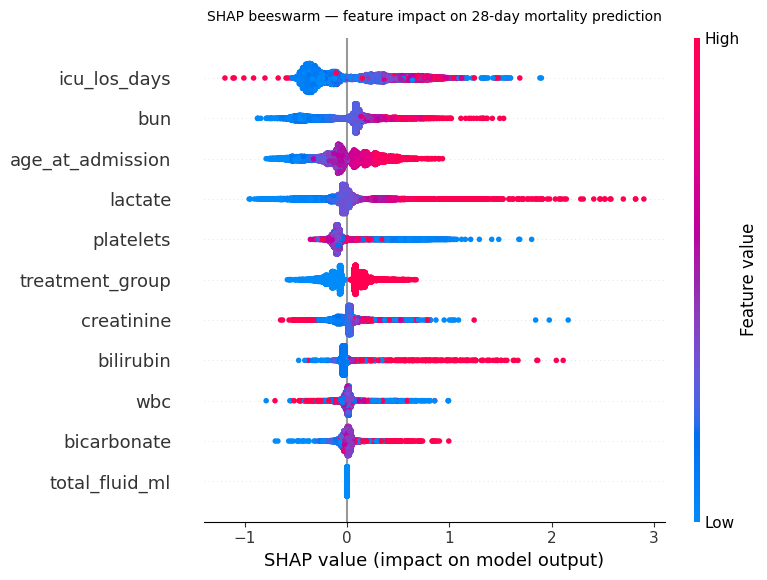

In [6]:
# ── 5. global importance — beeswarm plot ─────────────────────────────────────
# Each dot = one patient
# x-axis = SHAP value (impact on model output)
# color = feature value (red = high, blue = low)
# This is the single most informative SHAP plot — use it in your README

shap.summary_plot(shap_values, X, plot_type="dot", max_display=11, show=False)
plt.title(
    "SHAP beeswarm — feature impact on 28-day mortality prediction", fontsize=10, pad=12
)
plt.tight_layout()
plt.savefig("../figures/04_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()


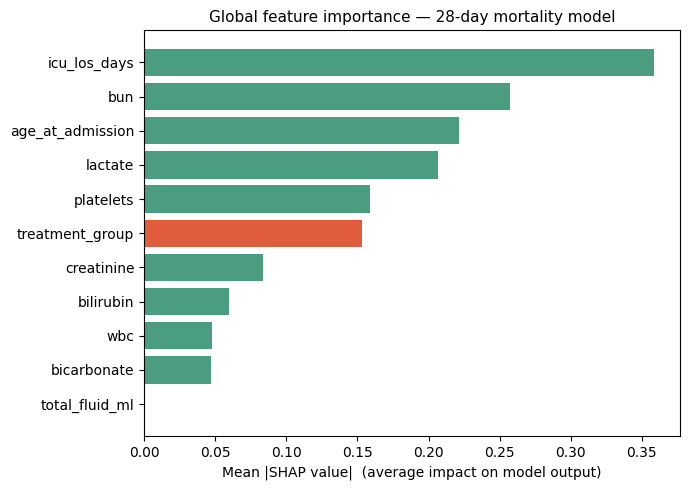

In [7]:
# ── 6. global importance — bar plot (cleaner for README) ─────────────────────

fig, ax = plt.subplots(figsize=(7, 5))

colors = [
    "#e05c3a" if f == "treatment_group" else "#4a9e7f" for f in mean_abs_shap.index
]

ax.barh(
    mean_abs_shap.index[::-1],
    mean_abs_shap.values[::-1],
    color=colors[::-1],
    edgecolor="none",
)
ax.set_xlabel("Mean |SHAP value|  (average impact on model output)")
ax.set_title("Global feature importance — 28-day mortality model", fontsize=11)

plt.tight_layout()
plt.savefig("../figures/04_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()


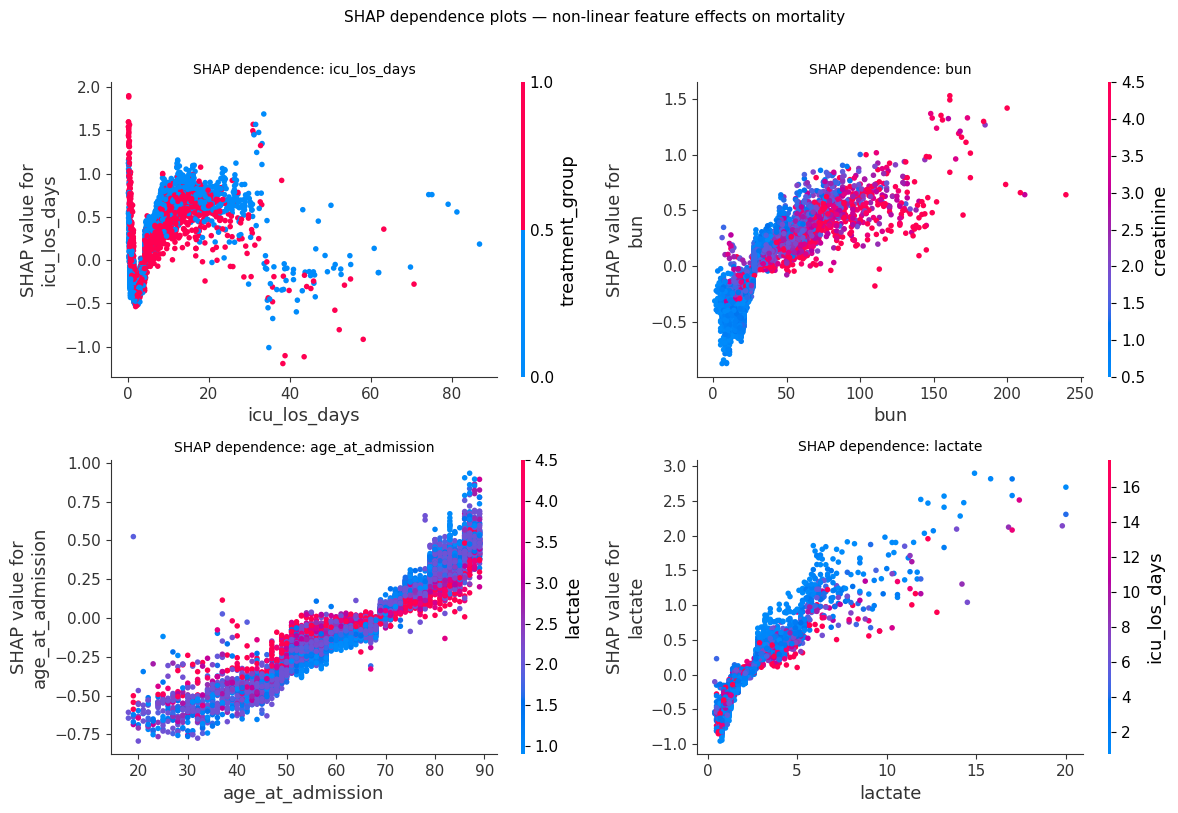

In [8]:
# ── 7. dependence plots for top 4 features ───────────────────────────────────
# Shows how SHAP value changes across the range of a feature
# Reveals non-linear effects and thresholds the Cox model can't capture
# Color = interaction effect with the most correlated other feature (auto)

top_features = mean_abs_shap.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    shap.dependence_plot(feat, shap_values, X, ax=axes[i], show=False)
    axes[i].set_title(f"SHAP dependence: {feat}", fontsize=10)

plt.suptitle(
    "SHAP dependence plots — non-linear feature effects on mortality",
    fontsize=11,
    y=1.01,
)
plt.tight_layout()
plt.savefig("../figures/04_shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()


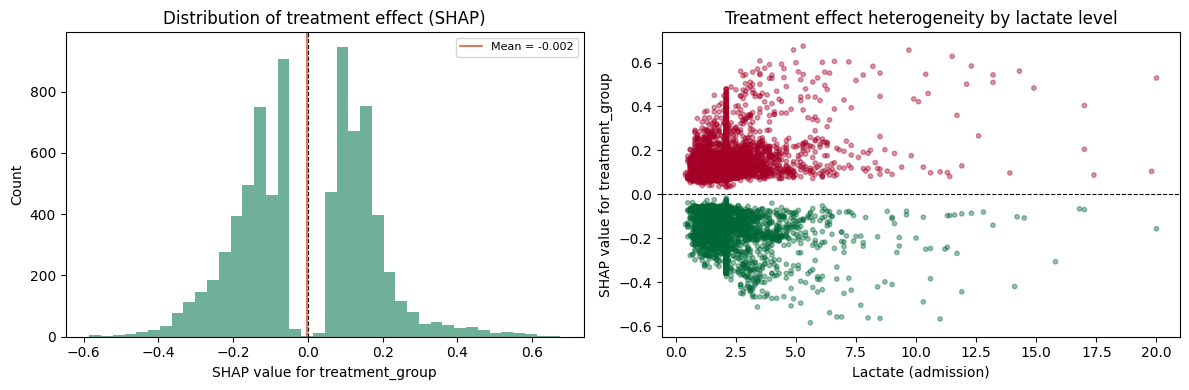

Mean treatment SHAP: -0.0017
Patients where vasopressor → higher mortality risk (SHAP > 0): 3,916 (50.0%)
Patients where vasopressor → lower mortality risk (SHAP < 0): 3,916 (50.0%)


In [9]:
# ── 8. treatment group SHAP — the key clinical question ──────────────────────
# Isolate just the SHAP values for treatment_group
# Positive SHAP = vasopressor associated with higher mortality for that patient
# Negative SHAP = vasopressor associated with lower mortality for that patient
# This reveals treatment effect heterogeneity — who benefits, who doesn't

treatment_idx = FEATURES.index("treatment_group")
treatment_shap = shap_values[:, treatment_idx]

treated = model_df[model_df["treatment_group"] == 1]
controls = model_df[model_df["treatment_group"] == 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# distribution of treatment SHAP values
axes[0].hist(treatment_shap, bins=40, color="#4a9e7f", edgecolor="none", alpha=0.8)
axes[0].axvline(0, color="black", linestyle="--", linewidth=0.8)
axes[0].axvline(
    treatment_shap.mean(),
    color="#e05c3a",
    linestyle="-",
    linewidth=1.2,
    label=f"Mean = {treatment_shap.mean():.3f}",
)
axes[0].set_xlabel("SHAP value for treatment_group")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of treatment effect (SHAP)")
axes[0].legend(fontsize=8)

# treatment SHAP vs lactate — does severity moderate treatment effect?
axes[1].scatter(
    model_df["lactate"],
    treatment_shap,
    c=model_df["treatment_group"],
    cmap="RdYlGn_r",
    alpha=0.4,
    s=10,
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("Lactate (admission)")
axes[1].set_ylabel("SHAP value for treatment_group")
axes[1].set_title("Treatment effect heterogeneity by lactate level")

plt.tight_layout()
plt.savefig("../figures/04_shap_treatment_effect.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean treatment SHAP: {treatment_shap.mean():.4f}")
print(
    f"Patients where vasopressor → higher mortality risk (SHAP > 0): "
    f"{(treatment_shap > 0).sum():,} ({(treatment_shap > 0).mean():.1%})"
)
print(
    f"Patients where vasopressor → lower mortality risk (SHAP < 0): "
    f"{(treatment_shap < 0).sum():,} ({(treatment_shap < 0).mean():.1%})"
)



=== High-risk patient ===
Predicted mortality probability: 97.8%
Actual outcome: died
Treatment: 1.0


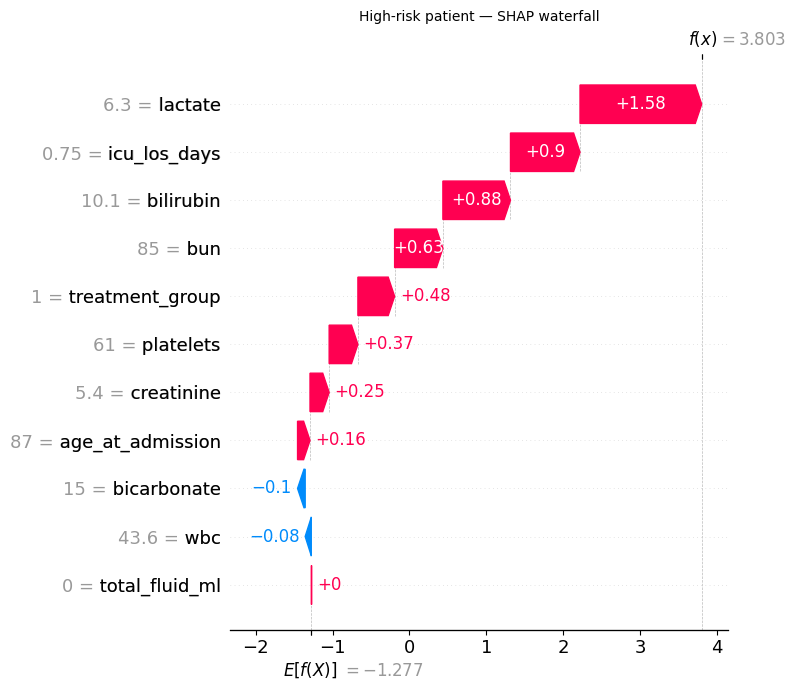


=== Low-risk patient ===
Predicted mortality probability: 2.1%
Actual outcome: survived
Treatment: 0.0


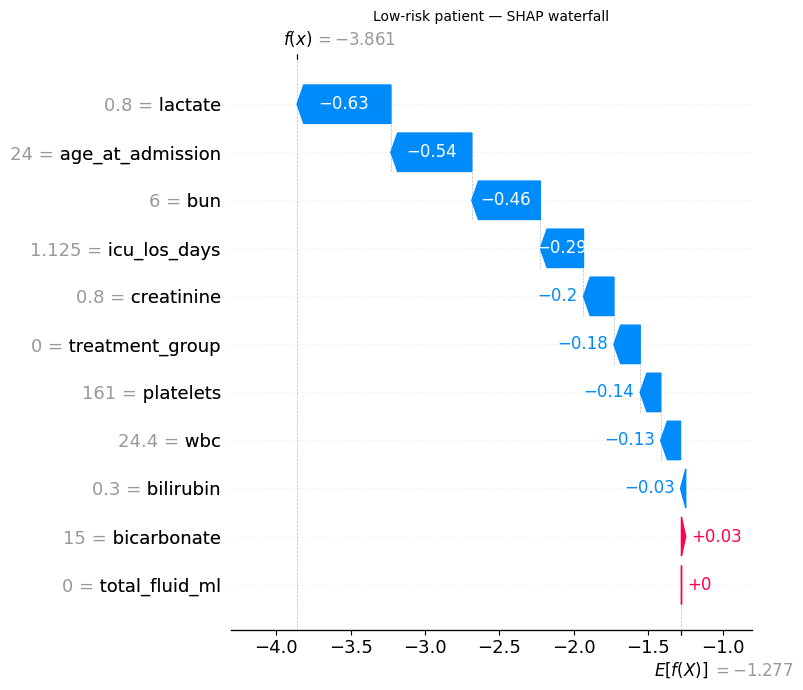

In [10]:
# ── 9. individual patient explanation ────────────────────────────────────────
# Pick one high-risk and one low-risk patient and explain their prediction
# Great for the README and for demonstrating to a clinical audience

# highest predicted mortality risk
high_risk_idx = y_pred_proba.argmax()

# lowest predicted mortality risk
low_risk_idx = y_pred_proba.argmin()

for label, idx in [
    ("High-risk patient", high_risk_idx),
    ("Low-risk patient", low_risk_idx),
]:
    print(f"\n=== {label} ===")
    print(f"Predicted mortality probability: {y_pred_proba[idx]:.1%}")
    print(f"Actual outcome: {'died' if y.iloc[idx] == 1 else 'survived'}")
    print(
        f"Treatment: {model_df.iloc[idx]['treatment_label'] if 'treatment_label' in model_df.columns else model_df.iloc[idx]['treatment_group']}"
    )

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X.iloc[idx].values,
            feature_names=FEATURES,
        ),
        show=False,
        max_display=11,
    )
    plt.title(f"{label} — SHAP waterfall", fontsize=10)
    plt.tight_layout()
    plt.savefig(
        f"../figures/04_shap_waterfall_{label.lower().replace(' ', '_')}.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()


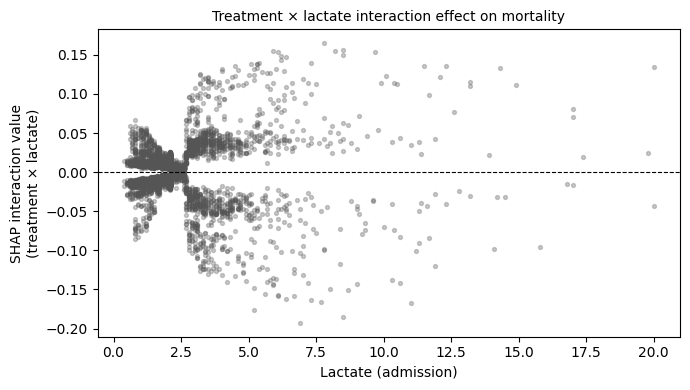

Mean |interaction|: 0.0188


In [11]:
# ── 10. SHAP interaction — lactate × treatment ────────────────────────────────
# Tests whether treatment effect depends on lactate level
# Clinically motivated: vasopressors may harm low-lactate patients
# who aren't truly in septic shock

shap_interaction = explainer.shap_interaction_values(X)

# interaction between treatment_group and lactate
treat_idx = FEATURES.index("treatment_group")
lactate_idx = FEATURES.index("lactate")

interaction_vals = shap_interaction[:, treat_idx, lactate_idx]

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(model_df["lactate"], interaction_vals, alpha=0.3, s=8, color="#555555")
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Lactate (admission)")
ax.set_ylabel("SHAP interaction value\n(treatment × lactate)")
ax.set_title("Treatment × lactate interaction effect on mortality", fontsize=10)
plt.tight_layout()
plt.savefig("../figures/04_shap_interaction_lactate.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean |interaction|: {np.abs(interaction_vals).mean():.4f}")


In [12]:
# ── 11. save SHAP outputs ─────────────────────────────────────────────────────

shap_df = pd.DataFrame(shap_values, columns=[f"shap_{f}" for f in FEATURES])
shap_df["predicted_mortality"] = y_pred_proba
shap_df["actual_outcome"] = y.values

shap_df.to_parquet("../data/shap_values.parquet", index=False)
mean_abs_shap.to_json("../data/shap_importance.json")

print("Saved shap_values.parquet and shap_importance.json")

print("\n=== Notebook 04 complete ===")
print("Project notebooks complete. Final outputs:")
print("  figures/03_km_curves_matched.png   ← lead figure for README")
print("  figures/03_forest_plot.png         ← primary results table")
print("  figures/04_shap_beeswarm.png       ← feature importance")
print("  figures/04_shap_treatment_effect.png ← treatment heterogeneity")
print("  data/results_summary.json          ← numbers for writeup")


Saved shap_values.parquet and shap_importance.json

=== Notebook 04 complete ===
Project notebooks complete. Final outputs:
  figures/03_km_curves_matched.png   ← lead figure for README
  figures/03_forest_plot.png         ← primary results table
  figures/04_shap_beeswarm.png       ← feature importance
  figures/04_shap_treatment_effect.png ← treatment heterogeneity
  data/results_summary.json          ← numbers for writeup
